> **Note on the HYDRUS-1D reference simulation — known limitation**
>
> HYDRUS-1D is used here as a vertical-1-D variably-saturated reference. Its modified-Picard mixed-form Richards solver is known to lose convergence in the persistently-saturated, surface-ponded regime: when the soil column reaches hydrostatic equilibrium with the water table at the surface, the head gradient that drives the iteration collapses and the run can terminate before the requested simulation horizon. The `phydrus` driver returns a clean exit code in this case, so the failure is silent unless explicitly checked. This case does not reach that regime within the simulated horizon, so the HYDRUS reference covers the full window; the issue is documented here for cross-reference with the intensive-sand and intensive-sand-over-loam companion notebooks where it does manifest.
>
> See the manuscript section "Limits of the HYDRUS-1D reference and of synthetic-case verification" for the full discussion and supporting citations.

# GWSWEX vs HYDRUS-1D - basic / sand-loam

65-day synthetic column experiment comparing two GWSWEX solvers
against HYDRUS-1D. All values shown here are loaded directly from
`experiment_definitions.json` at the start of each cell - this header is
hand-mirrored for readability and is verified by the test harness to track
the JSON source of truth.

| Parameter | Value |
|-----------|-------|
| Column | 3.0 m, 150 layers @ 2.0 cm |
| Soil profile (top→bottom) | sand (33%), loam (67%) |
| Initial WT depth | 150 cm below surface |
| Warmup (days 0-5) | zero forcing |
| Wet (days 5-35) | P = 0.45, PE = 0.03, PT = 0 cm d⁻¹ |
| Dry (days 35-65) | P = 0, PE = 0.15, PT = 0.07 cm d⁻¹ |
| Root growth | linear, 0.05 → 0.6 m |

**GWSWEX explicit**: operator-split cascade with CFL sub-stepping (daily macro-steps).
**GWSWEX implicit**: mixed-form Richards + Picard/TDMA (hourly macro-steps).

Solver- and material-specific tuned parameters (`MODEL_PARAMS`, `ET_STRESS`,
`solver kwargs`) are taken from the `oat_tuned` section of the same JSON file.
Outputs (HYDRUS-1D workspace, NetCDF state files) land under
`outputs/basic/sand-loam/`.


In [ ]:
from __future__ import annotations
from datetime import datetime, timedelta
from pathlib import Path
import sys

import numpy as np
from gwswex import GWSWEXmodel

# All pre/post-processing, HYDRUS-1D drive, plotting and metrics live in the
# shared helper module so the cells below stay focused on GWSWEX itself.
sys.path.insert(0, str(Path('.').resolve()))
import _compare_helpers as ch

ch.setup_plot_style()

SETUP, SOIL_TAG = 'basic', 'sand-loam'
SPEC = ch.load_experiment(SETUP, SOIL_TAG)
print(
    f'Loaded SoT: setup={SPEC.setup}, soil={SPEC.soil_tag}, '
    f'T_TOTAL={SPEC.T_TOTAL_d} d, NL={SPEC.NL}, '
    f'tuned solvers: {list(SPEC.tuned)}'
)

Loaded SoT: setup=basic, soil=sand-loam, T_TOTAL=65 d, NL=150, tuned solvers: ['implicit', 'explicit']


In [ ]:
# ── HYDRUS-1D reference run (drive + parse via the helper) ───────────────────
# Top BC: basic = top_bc=3 (surface runoff); intensive = top_bc=2 (ponding).
HYD = ch.run_hydrus(SPEC)
print(
    f'HYDRUS-1D done in {HYD.wall_s:.2f} s, '
    f'WT range {HYD.gw_depth_cm.min():.1f}-{HYD.gw_depth_cm.max():.1f} cm, '
    f'cum AE={HYD.cum_ae_cm[-1]:.2f} cm, cum AT={HYD.cum_at_cm[-1]:.2f} cm, '
    f'final MB err={HYD.mb_err_cm[-1]:+.4f} cm'
)

INFO: Successfully wrote /Users/veethahavya/Desktop/gwswex/examples/gwswex-vs-hydrus1d/outputs/basic/sand-loam/phydrus/hydrus1d/SELECTOR.IN


INFO: Successfully wrote /Users/veethahavya/Desktop/gwswex/examples/gwswex-vs-hydrus1d/outputs/basic/sand-loam/phydrus/hydrus1d/PROFILE.DAT


INFO: Successfully wrote /Users/veethahavya/Desktop/gwswex/examples/gwswex-vs-hydrus1d/outputs/basic/sand-loam/phydrus/hydrus1d/ATMOSPH.IN


INFO: Hydrus-1D Simulation Successful.


HYDRUS-1D done in 1.06 s, WT range 90.6-150.0 cm, cum AE=1.10 cm, cum AT=1.22 cm, final MB err=+0.0166 cm


In [ ]:
# ── GWSWEX setup helper (basic setup: T='d', root growth) ───────────────────
def build_gwswex_basic(solver: str) -> GWSWEXmodel:
    """Build a fully-configured GWSWEXmodel for the basic-setup column.

    Tuned MODEL_PARAMS / ET_STRESS / set_solver kwargs come from the
    `oat_tuned` block of experiment_definitions.json (per soil, per solver).
    Initial UZ uses the -999 sentinel so the kernel hydrostatic-equilibrates
    against the supplied GW head.
    """
    cfg = SPEC.tuned[solver]
    out = SPEC.outputs_root / f'compare-{solver}.nc'
    out.parent.mkdir(parents=True, exist_ok=True)

    m = GWSWEXmodel(name=f'compare-{solver}', T='d', L='m', output_fpath=str(out))
    m.init_space(ne=1, nl=SPEC.NL, top=[[SPEC.Z_TOP]], bot=[list(SPEC.BNDS[1:])], sID=[SPEC.layer_mat_ids], vID=[[1]])
    for mat in SPEC.materials:
        m.add_material(**mat)
    m.add_vegetation(
        id=1,
        name='crop',
        root_depth_initial=SPEC.root_d_initial,
        root_depth_final=SPEC.root_d_final,
        root_growth_model=SPEC.root_growth_model,
        et_stress=cfg['et_stress'],
    )
    T0 = datetime(2024, 1, 1)
    m.init_time(
        start=T0,
        stop=T0 + timedelta(days=SPEC.T_TOTAL_d),
        dt=timedelta(hours=1) if solver == 'implicit' else timedelta(days=1),
        dt_min=timedelta(seconds=60),
        adaptive=True,
    )
    m.set_model_params(**cfg['model_params'])
    m.set_solver(solver=solver, **cfg['solver_params'])
    m.set_initial_conditions(gw=SPEC.Z_WT, sw=0.0, uz=-999)

    if solver == 'implicit':
        precip = np.repeat(SPEC.prec_native, 24)
        pet = np.repeat(SPEC.pet_native, 24)
        ptt = np.repeat(SPEC.ptt_native, 24)
    else:
        precip, pet, ptt = SPEC.prec_native, SPEC.pet_native, SPEC.ptt_native
    m.set_forcing(precip=precip, pet=pet, ptt=ptt)
    m.init()
    return m

In [ ]:
print('Running GWSWEX implicit ...')
m = build_gwswex_basic('implicit')
RES_I = ch.collect_basic(SPEC, m, steps_per_day=24)
RES_I.label = 'GWSWEX implicit'
print(f'  wall {RES_I.wall_s:.2f} s, ' f'WT @ end = {RES_I.gw_depth_cm[-1]:.1f} cm')

Running GWSWEX implicit ...


  wall 1.98 s, WT @ end = 90.5 cm


In [ ]:
print('Running GWSWEX explicit ...')
m = build_gwswex_basic('explicit')
RES_E = ch.collect_basic(SPEC, m, steps_per_day=1)
RES_E.label = 'GWSWEX explicit'
print(f'  wall {RES_E.wall_s:.2f} s, ' f'WT @ end = {RES_E.gw_depth_cm[-1]:.1f} cm')

Running GWSWEX explicit ...


  wall 3.49 s, WT @ end = 90.3 cm


In [ ]:
RUNS = {'GWSWEX implicit': RES_I, 'GWSWEX explicit': RES_E}

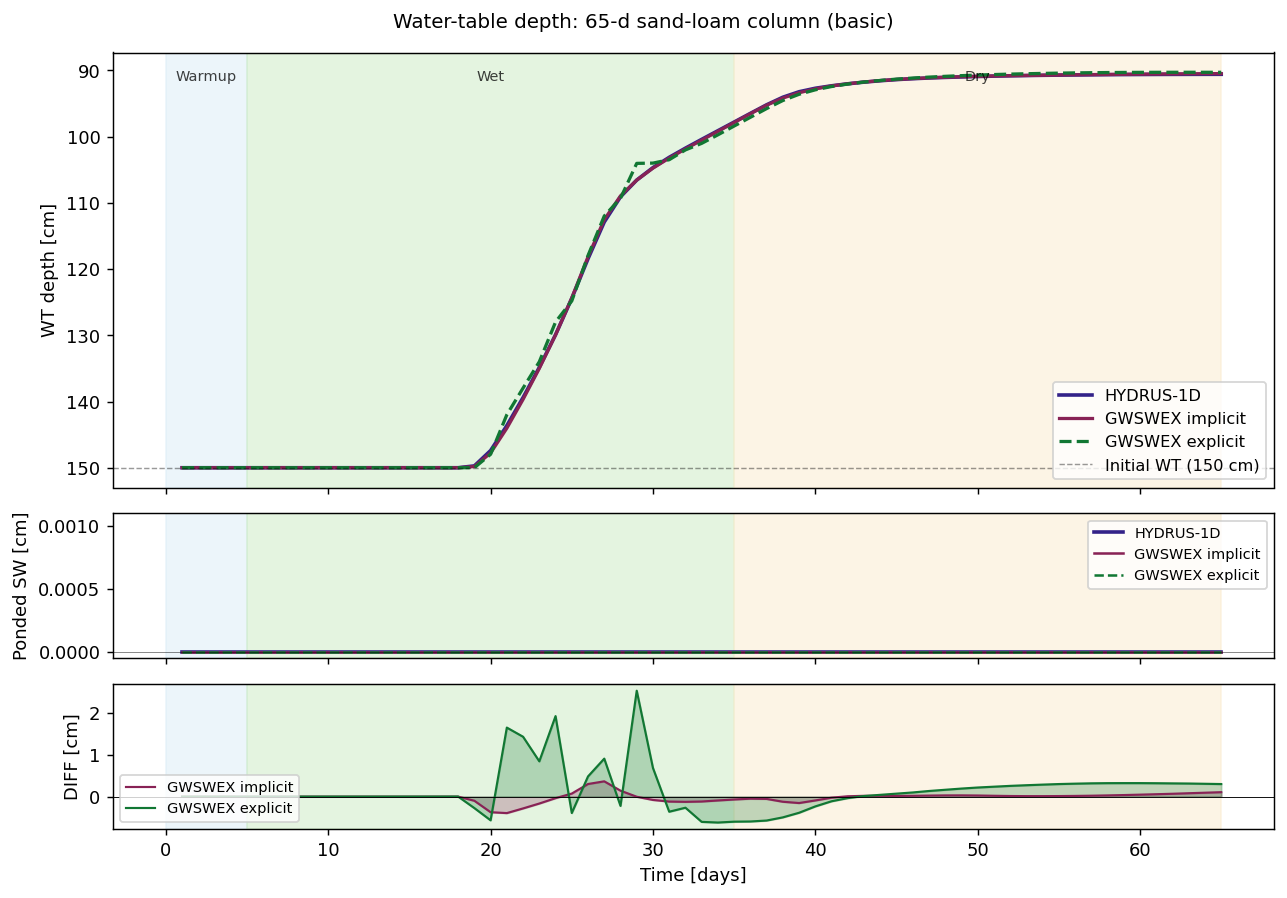

GWSWEX implicit: RMSE=0.11 cm, MAE=0.06 cm, NSE=1.000, Bias=+0.01 cm
GWSWEX explicit: RMSE=0.58 cm, MAE=0.34 cm, NSE=1.000, Bias=-0.15 cm


In [ ]:
ch.plot_water_table(SPEC, HYD, RUNS)

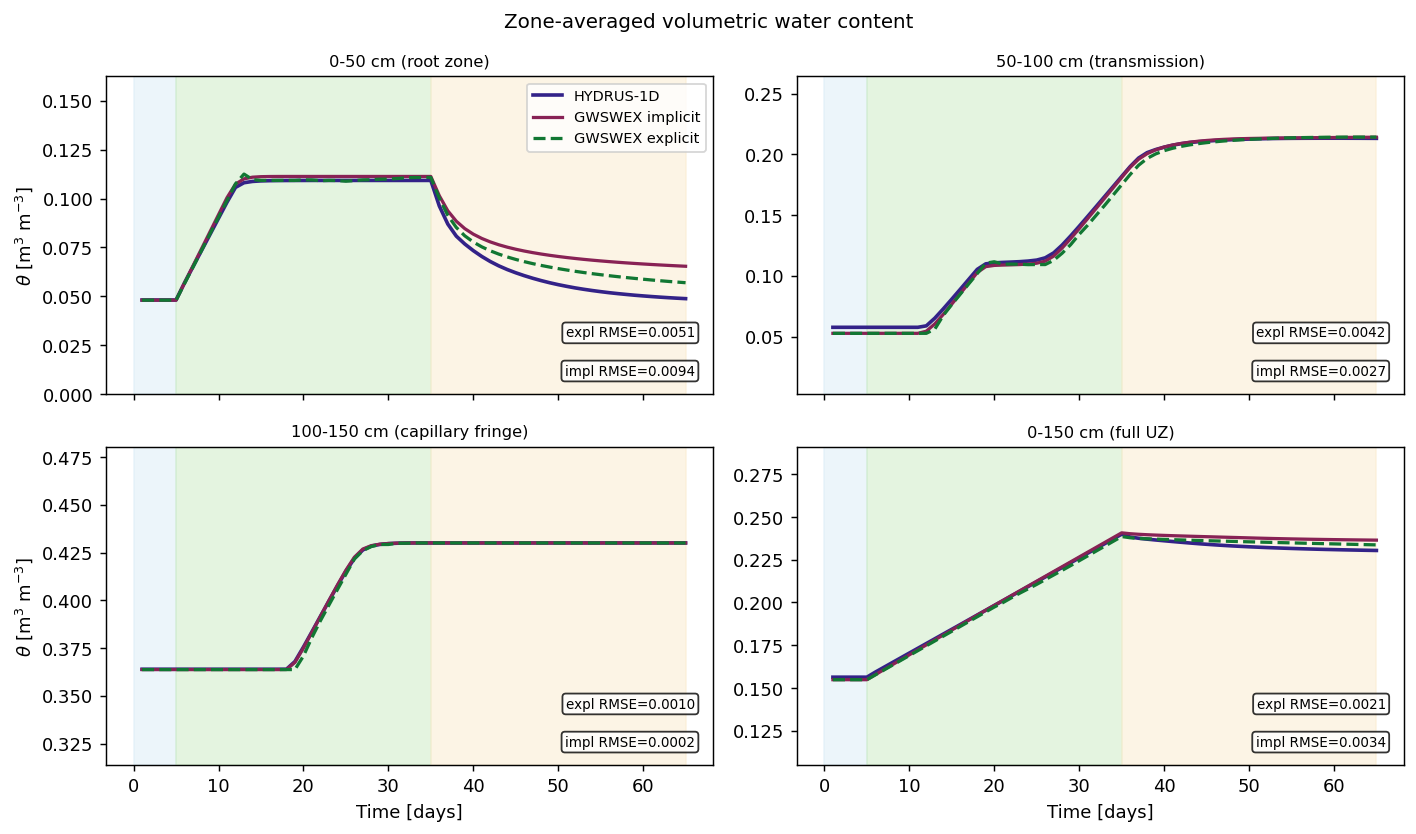

In [ ]:
ch.plot_zone_theta(
    SPEC,
    HYD,
    RUNS,
    zones=[
        (0, 50, '0-50 cm (root zone)'),
        (50, 100, '50-100 cm (transmission)'),
        (100, 150, '100-150 cm (capillary fringe)'),
        (0, 150, '0-150 cm (full UZ)'),
    ],
)

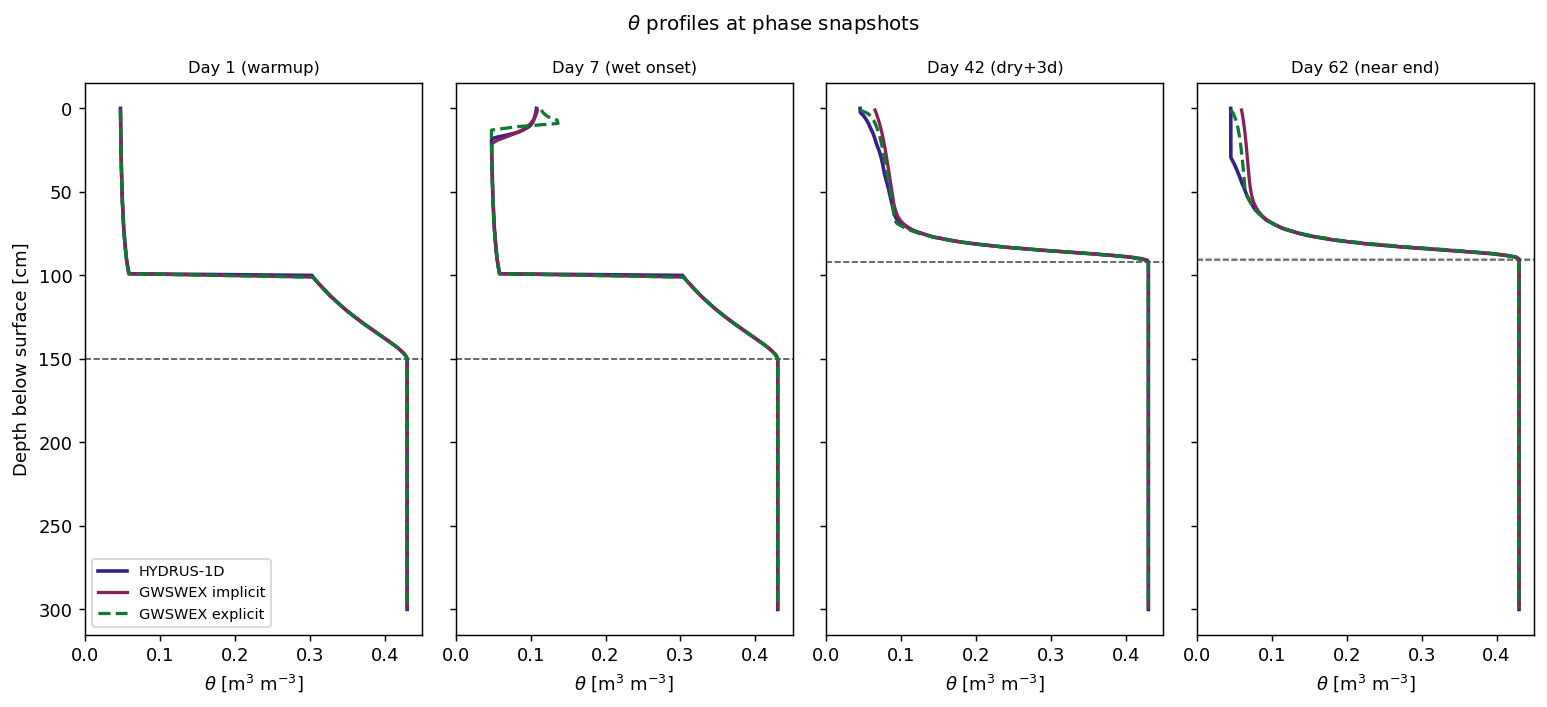

In [ ]:
ch.plot_theta_snapshots(
    SPEC,
    HYD,
    RUNS,
    snaps=[(0, 'Day 1 (warmup)'), (6, 'Day 7 (wet onset)'), (41, 'Day 42 (dry+3d)'), (61, 'Day 62 (near end)')],
)

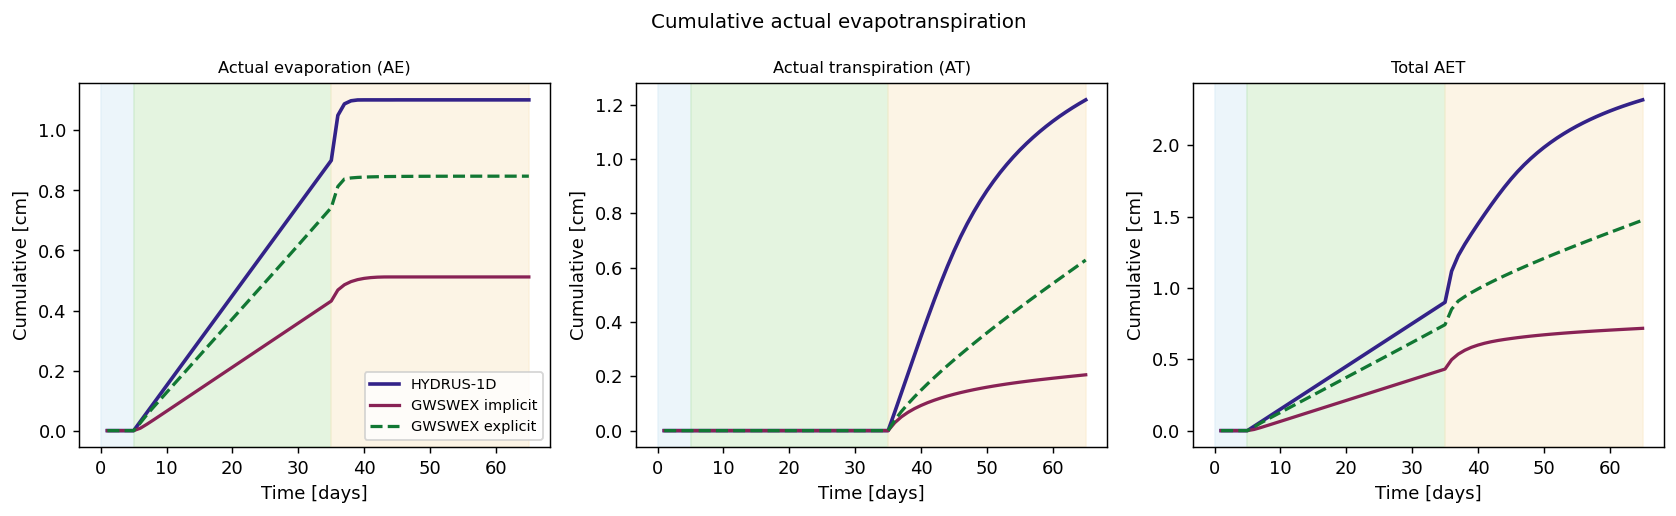

                             HYDRUS-1D  GWSWEX implicit  GWSWEX explicit
           Cum AE [cm]           1.102           0.512           0.847
           Cum AT [cm]           1.218           0.205           0.628
          Cum AET [cm]           2.319           0.717           1.475


In [ ]:
ch.plot_cum_et(SPEC, HYD, RUNS)

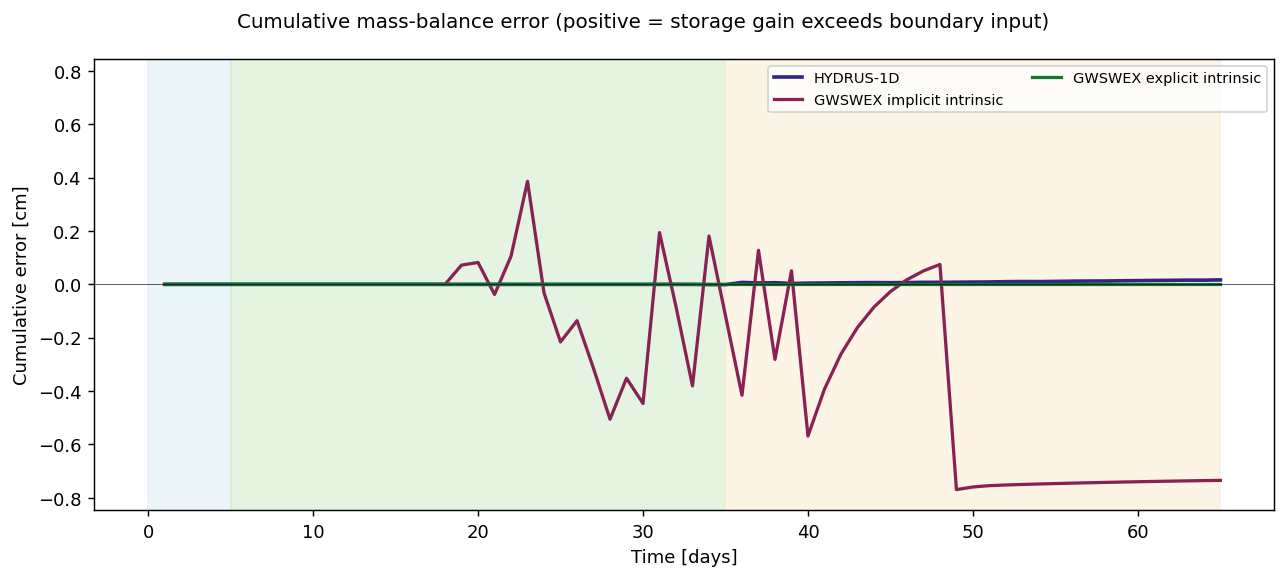


Cumulative MB error at t = 65 d
Model                        Final [cm]    Max |err| [cm]
------------------------------------------------------------
HYDRUS-1D                     +0.016600          0.016600
GWSWEX implicit intrinsic      -0.734612          0.769261
GWSWEX explicit intrinsic      +0.000000          0.000000


In [ ]:
ch.plot_mass_balance(SPEC, HYD, RUNS)

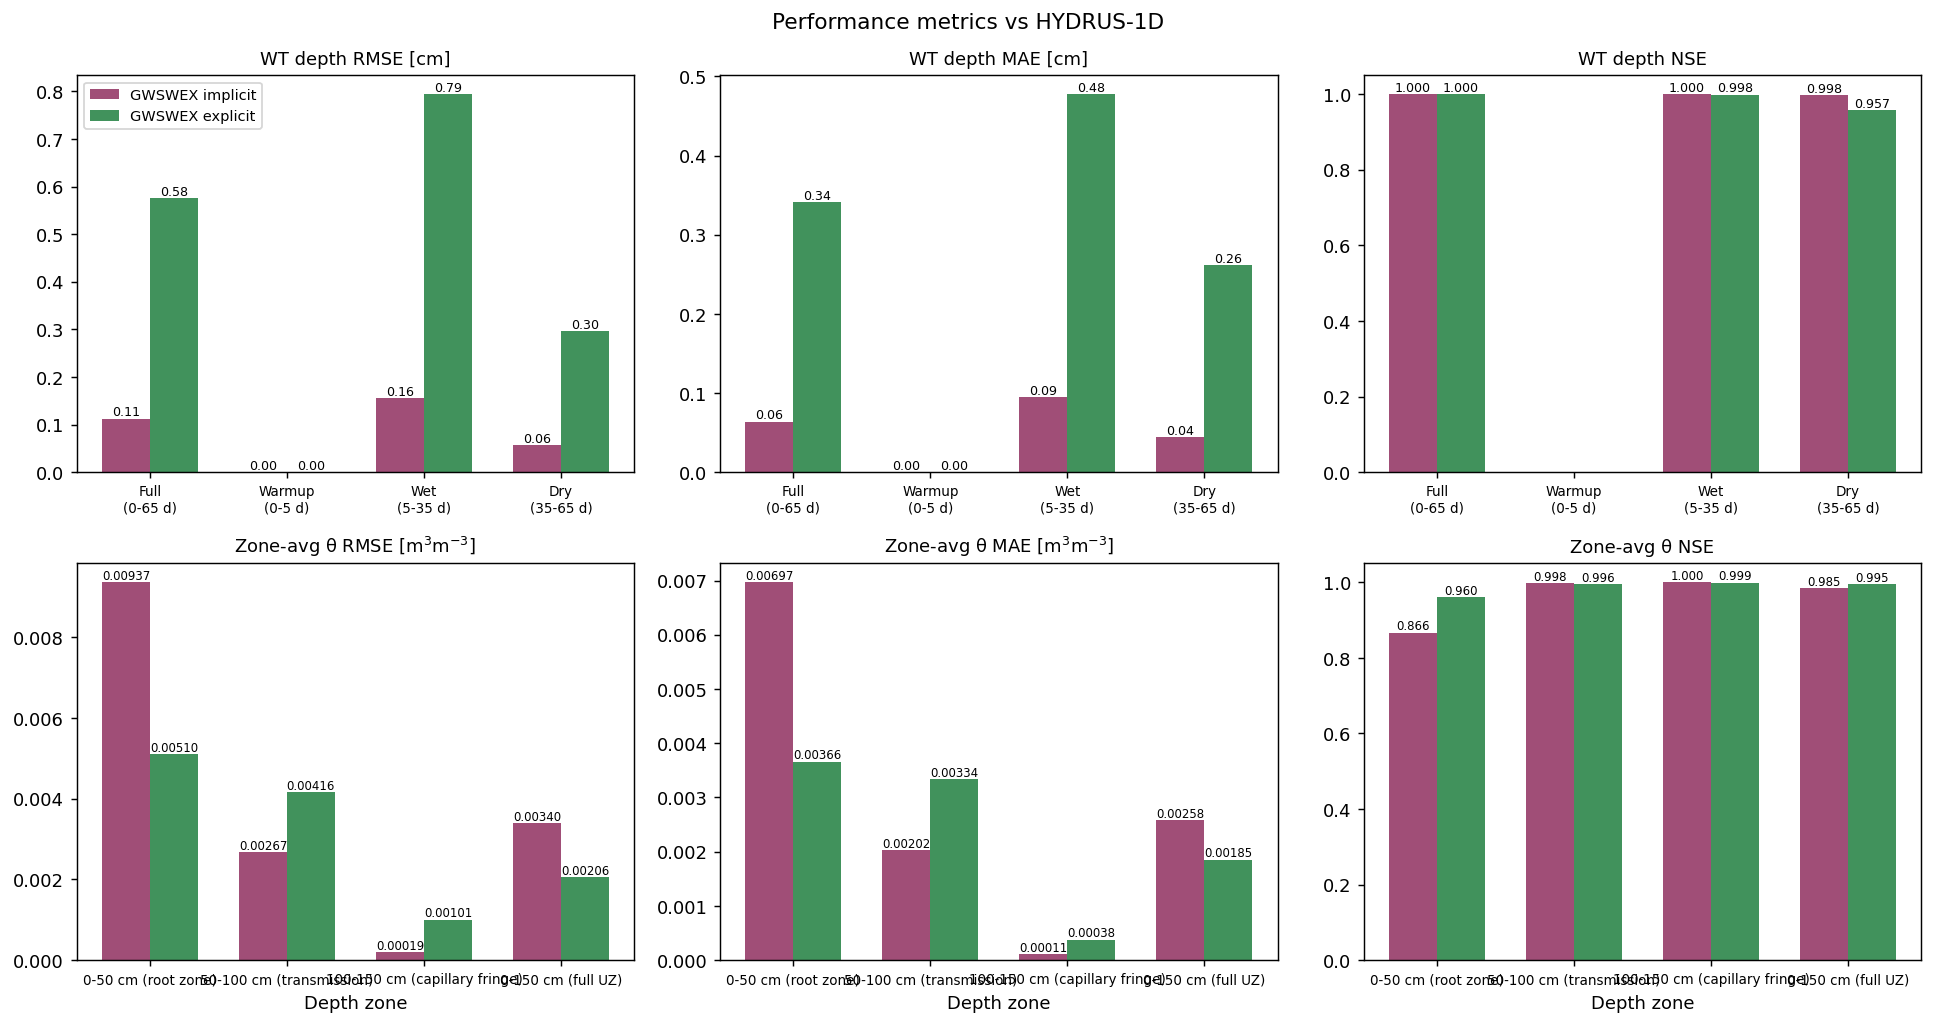

In [ ]:
ch.plot_metrics_summary(
    SPEC,
    HYD,
    RUNS,
    zone_specs=[
        (0, 50, '0-50 cm (root zone)'),
        (50, 100, '50-100 cm (transmission)'),
        (100, 150, '100-150 cm (capillary fringe)'),
        (0, 150, '0-150 cm (full UZ)'),
    ],
)